# Notebook 14 — Classification du type de panne

## Contexte

La détection multi-modale identifie les anomalies avec F1 = 100%.  
Mais elle ne dit pas **quel type de panne** — CPU ? Réseau ? Exception ?

Ce notebook ajoute une **classification supervisée** :  
étant donnée une anomalie détectée, prédire son type.

## Approche

- **Modèle** : Random Forest (robuste, non-linéaire)
- **Features** : 9 caractéristiques par fenêtre (modalités + scores + stats)
- **Labels** : 4 types de pannes (cpu_contention, exception, network_delay, return)
- **Validation** : Cross-validation 5-fold

## Utilité

Cette classification aide l'opérateur SRE à :
1. Comprendre rapidement le type de problème
2. Savoir où chercher (métriques CPU / logs / latence réseau / logique applicative)
3. Prioriser les investigations

In [2]:
import pickle
import csv
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timedelta
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

PROJET     = Path('/home/eunice/Bureau/Train_ticket/Intelligent_observability')
NORMAL     = PROJET / 'data/normal'
ANOMALIES  = PROJET / 'data/anomalies'
MODELS_DIR = PROJET / 'models'
OUTPUT     = PROJET / 'output'
RESULTS    = PROJET / 'results'
FIGURES    = PROJET / 'figures/classification_type'
FIGURES.mkdir(parents=True, exist_ok=True)

DATES_TT = ['2023-01-29', '2023-01-30']
DATES_OB = ['2022-08-22', '2022-08-23']
FEATURES_SPAN = ['duration_ms']

METRIQUES = [
    'CpuUsageRate(%)',
    'MemoryUsageRate(%)',
    'PodServerLatencyP99(s)',
    'NetworkReceiveBytes',
    'NetworkTransmitBytes',
]

# ─── Fonctions de chargement ───
def charger_metriques(date, source):
    metric_dir = source / date / 'metric'
    if not metric_dir.exists():
        return pd.DataFrame()
    dfs = []
    for f in sorted(metric_dir.glob('*_metric.csv')):
        service = f.stem.rsplit('-', 2)[0]
        df = pd.read_csv(f)
        df['service'] = service
        df['datetime'] = pd.to_datetime(df['TimeStamp'], unit='s', utc=True)
        for col in df.columns:
            if col not in ['Time', 'PodName', 'service', 'datetime']:
                df[col] = pd.to_numeric(df[col].replace('NaN', float('nan')), errors='coerce')
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

def charger_logs(date, source, fenetre):
    chemin = source / date / 'log' / f'{fenetre}_log.csv'
    if not chemin.exists():
        return pd.DataFrame()
    colonnes = ['Timestamp','TimeUnixNano','Node','PodName',
                'Container','TraceID','SpanID','Log']
    rows = []
    with open(chemin, 'r', encoding='utf-8', errors='replace') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) >= 8:
                rows.append(row[:8])
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows, columns=colonnes)
    df['service'] = df['PodName'].apply(lambda x: str(x).rsplit('-', 2)[0])
    df['template'] = df['Log'].apply(extraire_template)
    return df

def charger_traces(date, source, fenetre):
    chemin = source / date / 'trace' / f'{fenetre}_trace.csv'
    if not chemin.exists():
        return pd.DataFrame()
    df = pd.read_csv(chemin, on_bad_lines='skip')
    df['duration_ms'] = pd.to_numeric(df['Duration'], errors='coerce') / 1e6
    df['service'] = df['PodName'].apply(lambda x: str(x).rsplit('-', 2)[0])
    return df

def extraire_template(log_str):
    log_str = str(log_str)
    match = re.search(r'"log"\s*:\s*"([^"]+)"', log_str)
    if match: log_str = match.group(1)
    log_str = re.sub(r'[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}', '<UUID>', log_str)
    log_str = re.sub(r'[0-9a-f]{16,}', '<HEX>', log_str)
    log_str = re.sub(r'\b\d+\.?\d*\b', '<NUM>', log_str)
    crochets = re.findall(r'\[([^\]]+)\]', log_str)
    if crochets: return ' | '.join(crochets[:3])
    return ' '.join(log_str.split()[:6])

# ─── Ground truth ───
gt_tt = pd.read_csv(OUTPUT / 'ground_truth.csv')
gt_ob = pd.read_csv(OUTPUT / 'ground_truth_OB.csv')

print(f"Train Ticket    : {len(gt_tt)} fenêtres")
print(f"Online Boutique : {len(gt_ob)} fenêtres")
print(f"\nRépartition Train Ticket :")
print(gt_tt['fault_type'].value_counts())
print(f"\nRépartition Online Boutique :")
print(gt_ob['fault_type'].value_counts())

# Total
print(f"\nTotal fenêtres : {len(gt_tt) + len(gt_ob)}")

Train Ticket    : 135 fenêtres
Online Boutique : 168 fenêtres

Répartition Train Ticket :
fault_type
network_delay     42
exception         39
return            33
cpu_contention    21
Name: count, dtype: int64

Répartition Online Boutique :
fault_type
cpu_contention    48
network_delay     48
cpu_consumed      30
return            21
exception         21
Name: count, dtype: int64

Total fenêtres : 303


## 2. Extraction des features

Pour chaque fenêtre anormale, on extrait 9 features :

**Features booléennes (détection par modalité)** :
1. `metriques_detecte` : LOF détecte-t-il une anomalie ?
2. `logs_detecte` : TF-IDF détecte-t-il ?
3. `traces_detecte` : IF détecte-t-il ?

**Features continues (scores)** :
4. `score_metriques` : intensité de l'anomalie métriques
5. `score_logs` : intensité de l'anomalie logs
6. `score_traces` : taux de spans anormaux

**Features statistiques (contexte de la fenêtre)** :
7. `nb_logs` : nombre de logs
8. `nb_spans` : nombre de spans
9. `duree_moy_spans` : durée moyenne des spans

Ces 9 features caractérisent la fenêtre sous plusieurs angles.

In [3]:
# 
# CHARGER LES MODÈLES POUR EXTRAIRE LES SCORES
# 
print("=== Chargement des modèles ===\n")

# Train Ticket
with open(MODELS_DIR / 'lof_tt.pkl', 'rb') as f:
    lof_tt = pickle.load(f)
with open(MODELS_DIR / 'tfidf_tt.pkl', 'rb') as f:
    tfidf_tt = pickle.load(f)
with open(MODELS_DIR / 'if_traces_tt.pkl', 'rb') as f:
    if_tt = pickle.load(f)

# Online Boutique
with open(MODELS_DIR / 'lof_ob.pkl', 'rb') as f:
    lof_ob = pickle.load(f)
with open(MODELS_DIR / 'tfidf_ob.pkl', 'rb') as f:
    tfidf_ob = pickle.load(f)
with open(MODELS_DIR / 'if_traces_ob.pkl', 'rb') as f:
    if_ob = pickle.load(f)

print("✓ Tous les modèles chargés\n")

# 
# FONCTION D'EXTRACTION DES FEATURES
# 
SEUILS_TFIDF = {'train_ticket': 0.95, 'online_boutique': 0.7}
SEUIL_IF = 0.12

def extraire_features(row, systeme):
    """
    Extrait 9 features pour une fenêtre donnée.
    """
    # Charger les modèles selon le système
    if systeme == 'train_ticket':
        lof_data, tfidf_data, if_data = lof_tt, tfidf_tt, if_tt
        source = ANOMALIES
    else:
        lof_data, tfidf_data, if_data = lof_ob, tfidf_ob, if_ob
        source = ANOMALIES
    
    date, window = row['date'], row['window']
    
    # ─── MÉTRIQUES ───
    df_metriques = charger_metriques(date, source)
    if not df_metriques.empty:
        h, m = map(int, window.split('_'))
        t_debut = pd.Timestamp(f"{date} {h:02d}:{m:02d}:00").tz_localize('UTC')
        t_fin = t_debut + timedelta(minutes=1)
        mask = (df_metriques['datetime'] >= t_debut) & (df_metriques['datetime'] < t_fin)
        df_fen_met = df_metriques[mask]
    else:
        df_fen_met = pd.DataFrame()
    
    metriques_detecte = False
    score_metriques = 0.0
    if not df_fen_met.empty:
        for service in df_fen_met['service'].unique():
            if service not in lof_data['modeles']:
                continue
            df_svc = df_fen_met[df_fen_met['service'] == service][METRIQUES].dropna()
            if df_svc.empty:
                continue
            X = lof_data['scalers'][service].transform(df_svc)
            pred = lof_data['modeles'][service].predict(X)
            scores = lof_data['modeles'][service].decision_function(X)
            if (pred == -1).any():
                metriques_detecte = True
            score_metriques = max(score_metriques, -scores.min())
    
    # ─── LOGS ───
    df_logs = charger_logs(date, source, window)
    logs_detecte = False
    score_logs = 0.0
    nb_logs = len(df_logs)
    
    if not df_logs.empty:
        texte = ' '.join(df_logs['template'].tolist())
        if texte.strip():
            vecteur = tfidf_data['vectorizer'].transform([texte])
            sim = cosine_similarity(vecteur, tfidf_data['vecteur_ref'].reshape(1, -1))[0, 0]
            score_logs = 1 - sim
            if sim < SEUILS_TFIDF[systeme]:
                logs_detecte = True
    
    # ─── TRACES ───
    df_traces = charger_traces(date, source, window)
    traces_detecte = False
    score_traces = 0.0
    nb_spans = len(df_traces)
    duree_moy_spans = 0.0
    
    if not df_traces.empty:
        duree_moy_spans = df_traces['duration_ms'].mean()
        nb_anomalies, nb_total = 0, 0
        for service in df_traces['service'].unique():
            if service not in if_data['modeles']:
                continue
            df_svc = df_traces[df_traces['service'] == service][['duration_ms']].dropna()
            if df_svc.empty:
                continue
            X = if_data['scalers'][service].transform(df_svc)
            pred = if_data['modeles'][service].predict(X)
            nb_anomalies += (pred == -1).sum()
            nb_total += len(pred)
        if nb_total > 0:
            score_traces = nb_anomalies / nb_total
            traces_detecte = score_traces > SEUIL_IF
    
    return {
        'metriques_detecte': int(metriques_detecte),
        'logs_detecte'     : int(logs_detecte),
        'traces_detecte'   : int(traces_detecte),
        'score_metriques'  : float(score_metriques),
        'score_logs'       : float(score_logs),
        'score_traces'     : float(score_traces),
        'nb_logs'          : int(nb_logs),
        'nb_spans'         : int(nb_spans),
        'duree_moy_spans'  : float(duree_moy_spans),
    }

print("✓ Fonction d'extraction prête")

=== Chargement des modèles ===

✓ Tous les modèles chargés

✓ Fonction d'extraction prête


In [4]:
# ═══════════════════════════════════════════
# EXTRACTION DES FEATURES SUR TOUT LE DATASET
# ═══════════════════════════════════════════
print("=== Extraction des features ===\n")

features_list = []
labels_list = []
systemes_list = []

# ─── Train Ticket ───
print("Traitement Train Ticket (135 fenêtres)...")
for i, row in gt_tt.iterrows():
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(gt_tt)}")
    features = extraire_features(row, 'train_ticket')
    features_list.append(features)
    labels_list.append(row['fault_type'])
    systemes_list.append('train_ticket')

# ─── Online Boutique ───
print(f"\nTraitement Online Boutique (168 fenêtres)...")
for i, row in gt_ob.iterrows():
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(gt_ob)}")
    features = extraire_features(row, 'online_boutique')
    features_list.append(features)
    labels_list.append(row['fault_type'])
    systemes_list.append('online_boutique')

# Construire le DataFrame final
df_features = pd.DataFrame(features_list)
df_features['fault_type'] = labels_list
df_features['systeme']    = systemes_list

print(f"\n✓ Features extraites : {df_features.shape}")
print(f"\nAperçu :")
print(df_features.head())
print(f"\nStatistiques :")
print(df_features.describe())

# Sauvegarder pour éviter de recalculer
df_features.to_csv(RESULTS / 'features_classification_type.csv', index=False)
print(f"\n✓ Sauvegardé dans results/features_classification_type.csv")

=== Extraction des features ===

Traitement Train Ticket (135 fenêtres)...
  20/135
  40/135
  60/135
  80/135
  100/135
  120/135

Traitement Online Boutique (168 fenêtres)...
  20/168
  40/168
  60/168
  80/168
  100/168
  120/168
  140/168
  160/168

✓ Features extraites : (303, 11)

Aperçu :
   metriques_detecte  logs_detecte  traces_detecte  score_metriques  \
0                  1             0               1         0.694226   
1                  1             1               1         1.161553   
2                  1             1               0         1.151814   
3                  1             1               1         0.983359   
4                  1             0               1         1.602318   

   score_logs  score_traces  nb_logs  nb_spans  duree_moy_spans fault_type  \
0    0.045348      0.121710     2435      4445         0.021688     return   
1    0.144763      0.184227     2622      4907         0.029453     return   
2    0.122382      0.118442     2795      

## 3. Entraînement du Random Forest

On entraîne un classificateur Random Forest sur les 303 fenêtres.  
Cross-validation 5-fold pour valider la robustesse.

In [8]:
# ═══════════════════════════════════════════
# ENTRAÎNEMENT DU RANDOM FOREST
# ═══════════════════════════════════════════
print("=== Entraînement Random Forest ===\n")

FEATURES = [
    'metriques_detecte', 'logs_detecte', 'traces_detecte',
    'score_metriques', 'score_logs', 'score_traces',
    'nb_logs', 'nb_spans', 'duree_moy_spans',
]

# Conversion propre en numpy
X = df_features[FEATURES].to_numpy().astype(float)
y = df_features['fault_type'].to_numpy()

print(f"X shape : {X.shape}")
print(f"y unique : {sorted(set(y))}")
print(f"\nDistribution des classes :")
for classe, count in sorted(Counter(y).items()):
    print(f"  {classe:<20} : {count} ({count/len(y)*100:.1f}%)")

# ─── Cross-validation 5-fold ───
print("\n=== Cross-validation 5-fold ===")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1,
)

scores_cv = cross_val_score(rf, X, y, cv=5, scoring='f1_weighted')
print(f"\n  F1-weighted par fold : {scores_cv}")
print(f"  Moyenne              : {scores_cv.mean():.3f} ± {scores_cv.std():.3f}")

# ─── Cross-validation predictions ───
print("\n=== Rapport de classification (cross-validation) ===")
y_pred = cross_val_predict(rf, X, y, cv=5, n_jobs=-1)
print(classification_report(y, y_pred, digits=3))

# ─── Matrice de confusion ───
print("\n=== Matrice de confusion ===")
classes_ordre = sorted(set(y))
cm = confusion_matrix(y, y_pred, labels=classes_ordre)
print(f"\nClasses : {classes_ordre}")
print(pd.DataFrame(cm, index=classes_ordre, columns=classes_ordre))

=== Entraînement Random Forest ===

X shape : (303, 9)
y unique : ['cpu_consumed', 'cpu_contention', 'exception', 'network_delay', 'return']

Distribution des classes :
  cpu_consumed         : 30 (9.9%)
  cpu_contention       : 69 (22.8%)
  exception            : 60 (19.8%)
  network_delay        : 90 (29.7%)
  return               : 54 (17.8%)

=== Cross-validation 5-fold ===

  F1-weighted par fold : [0.50585293 0.49418532 0.37008935 0.44415729 0.36817496]
  Moyenne              : 0.436 ± 0.059

=== Rapport de classification (cross-validation) ===
                precision    recall  f1-score   support

  cpu_consumed      0.281     0.300     0.290        30
cpu_contention      0.442     0.493     0.466        69
     exception      0.333     0.283     0.306        60
 network_delay      0.540     0.600     0.568        90
        return      0.558     0.444     0.495        54

      accuracy                          0.455       303
     macro avg      0.431     0.424     0.425    

## 4. Enrichissement des features

Ajout de features spécifiques par métrique pour mieux distinguer les types de pannes :

**Métriques spécifiques (par service anormal)** :
- CPU moyen, max, écart-type
- Mémoire moyenne, max
- Latence P99 moyenne, max
- Bytes réseau (in/out) totaux

Ces features devraient permettre de distinguer :
- `cpu_consumed` (CPU max très élevé)
- `cpu_contention` (CPU moyen élevé mais variable)
- `network_delay` (bytes réseau anormaux + latence P99)
- `exception` (patterns différents)
- `return` (comportement subtil)

In [9]:
# ═══════════════════════════════════════════
# ENRICHISSEMENT DES FEATURES
# ═══════════════════════════════════════════
print("=== Enrichissement des features ===\n")

def extraire_features_enrichies(row, systeme):
    """
    Version enrichie avec des features détaillées par métrique.
    """
    # Charger les modèles selon le système
    if systeme == 'train_ticket':
        lof_data, tfidf_data, if_data = lof_tt, tfidf_tt, if_tt
    else:
        lof_data, tfidf_data, if_data = lof_ob, tfidf_ob, if_ob
    
    source = ANOMALIES
    date, window = row['date'], row['window']
    
    # ─── MÉTRIQUES ENRICHIES ───
    df_metriques = charger_metriques(date, source)
    
    # Features par défaut
    features_met = {
        'metriques_detecte': 0,
        'score_metriques'  : 0.0,
        'cpu_mean'         : 0.0, 'cpu_max'      : 0.0, 'cpu_std'      : 0.0,
        'mem_mean'         : 0.0, 'mem_max'      : 0.0,
        'lat_p99_mean'     : 0.0, 'lat_p99_max'  : 0.0,
        'net_rx_total'     : 0.0, 'net_tx_total' : 0.0,
    }
    
    if not df_metriques.empty:
        h, m = map(int, window.split('_'))
        t_debut = pd.Timestamp(f"{date} {h:02d}:{m:02d}:00").tz_localize('UTC')
        t_fin = t_debut + timedelta(minutes=1)
        mask = (df_metriques['datetime'] >= t_debut) & (df_metriques['datetime'] < t_fin)
        df_fen = df_metriques[mask]
        
        if not df_fen.empty:
            # Détection LOF
            metriques_detecte = False
            score_max = 0.0
            for service in df_fen['service'].unique():
                if service not in lof_data['modeles']:
                    continue
                df_svc = df_fen[df_fen['service'] == service][METRIQUES].dropna()
                if df_svc.empty:
                    continue
                X = lof_data['scalers'][service].transform(df_svc)
                pred = lof_data['modeles'][service].predict(X)
                scores = lof_data['modeles'][service].decision_function(X)
                if (pred == -1).any():
                    metriques_detecte = True
                score_max = max(score_max, -scores.min())
            
            features_met['metriques_detecte'] = int(metriques_detecte)
            features_met['score_metriques']   = float(score_max)
            
            # Statistiques par métrique
            cpu = df_fen['CpuUsageRate(%)'].dropna()
            if len(cpu) > 0:
                features_met['cpu_mean'] = float(cpu.mean())
                features_met['cpu_max']  = float(cpu.max())
                features_met['cpu_std']  = float(cpu.std()) if len(cpu) > 1 else 0.0
            
            mem = df_fen['MemoryUsageRate(%)'].dropna()
            if len(mem) > 0:
                features_met['mem_mean'] = float(mem.mean())
                features_met['mem_max']  = float(mem.max())
            
            lat = df_fen['PodServerLatencyP99(s)'].dropna()
            if len(lat) > 0:
                features_met['lat_p99_mean'] = float(lat.mean())
                features_met['lat_p99_max']  = float(lat.max())
            
            net_rx = df_fen['NetworkReceiveBytes'].dropna()
            if len(net_rx) > 0:
                features_met['net_rx_total'] = float(net_rx.sum())
            
            net_tx = df_fen['NetworkTransmitBytes'].dropna()
            if len(net_tx) > 0:
                features_met['net_tx_total'] = float(net_tx.sum())
    
    # ─── LOGS ───
    df_logs = charger_logs(date, source, window)
    logs_detecte = False
    score_logs = 0.0
    nb_logs = len(df_logs)
    
    if not df_logs.empty:
        texte = ' '.join(df_logs['template'].tolist())
        if texte.strip():
            vecteur = tfidf_data['vectorizer'].transform([texte])
            sim = cosine_similarity(vecteur, tfidf_data['vecteur_ref'].reshape(1, -1))[0, 0]
            score_logs = 1 - sim
            if sim < SEUILS_TFIDF[systeme]:
                logs_detecte = True
    
    # ─── TRACES ───
    df_traces = charger_traces(date, source, window)
    traces_detecte = False
    score_traces = 0.0
    nb_spans = len(df_traces)
    duree_moy_spans = 0.0
    duree_max_spans = 0.0
    duree_std_spans = 0.0
    
    if not df_traces.empty:
        durees = df_traces['duration_ms'].dropna()
        if len(durees) > 0:
            duree_moy_spans = float(durees.mean())
            duree_max_spans = float(durees.max())
            duree_std_spans = float(durees.std()) if len(durees) > 1 else 0.0
        
        nb_anomalies, nb_total = 0, 0
        for service in df_traces['service'].unique():
            if service not in if_data['modeles']:
                continue
            df_svc = df_traces[df_traces['service'] == service][['duration_ms']].dropna()
            if df_svc.empty:
                continue
            X = if_data['scalers'][service].transform(df_svc)
            pred = if_data['modeles'][service].predict(X)
            nb_anomalies += (pred == -1).sum()
            nb_total += len(pred)
        if nb_total > 0:
            score_traces = nb_anomalies / nb_total
            traces_detecte = score_traces > SEUIL_IF
    
    return {
        **features_met,
        'logs_detecte'    : int(logs_detecte),
        'score_logs'      : float(score_logs),
        'nb_logs'         : int(nb_logs),
        'traces_detecte'  : int(traces_detecte),
        'score_traces'    : float(score_traces),
        'nb_spans'        : int(nb_spans),
        'duree_moy_spans' : float(duree_moy_spans),
        'duree_max_spans' : float(duree_max_spans),
        'duree_std_spans' : float(duree_std_spans),
    }

# ─── Ré-extraction avec features enrichies ───
print("Ré-extraction avec features enrichies...")

features_enrichies = []
labels_new = []
systemes_new = []

print("\nTrain Ticket...")
for i, row in gt_tt.iterrows():
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(gt_tt)}")
    f = extraire_features_enrichies(row, 'train_ticket')
    features_enrichies.append(f)
    labels_new.append(row['fault_type'])
    systemes_new.append('train_ticket')

print("\nOnline Boutique...")
for i, row in gt_ob.iterrows():
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(gt_ob)}")
    f = extraire_features_enrichies(row, 'online_boutique')
    features_enrichies.append(f)
    labels_new.append(row['fault_type'])
    systemes_new.append('online_boutique')

df_features_v2 = pd.DataFrame(features_enrichies)
df_features_v2['fault_type'] = labels_new
df_features_v2['systeme']    = systemes_new

print(f"\n✓ Features enrichies : {df_features_v2.shape}")
print(f"\nColonnes ({len(df_features_v2.columns) - 2} features) :")
for col in df_features_v2.columns:
    if col not in ['fault_type', 'systeme']:
        print(f"  - {col}")

df_features_v2.to_csv(RESULTS / 'features_classification_enrichies.csv', index=False)

=== Enrichissement des features ===

Ré-extraction avec features enrichies...

Train Ticket...
  20/135
  40/135
  60/135
  80/135
  100/135
  120/135

Online Boutique...
  20/168
  40/168
  60/168
  80/168
  100/168
  120/168
  140/168
  160/168

✓ Features enrichies : (303, 22)

Colonnes (20 features) :
  - metriques_detecte
  - score_metriques
  - cpu_mean
  - cpu_max
  - cpu_std
  - mem_mean
  - mem_max
  - lat_p99_mean
  - lat_p99_max
  - net_rx_total
  - net_tx_total
  - logs_detecte
  - score_logs
  - nb_logs
  - traces_detecte
  - score_traces
  - nb_spans
  - duree_moy_spans
  - duree_max_spans
  - duree_std_spans


In [10]:
# ═══════════════════════════════════════════
# ENTRAÎNEMENT AVEC FEATURES ENRICHIES
# ═══════════════════════════════════════════
print("=== Entraînement Random Forest V2 (features enrichies) ===\n")

FEATURES_V2 = [c for c in df_features_v2.columns if c not in ['fault_type', 'systeme']]
print(f"Nombre de features : {len(FEATURES_V2)}")

X_v2 = df_features_v2[FEATURES_V2].to_numpy().astype(float)
y_v2 = df_features_v2['fault_type'].to_numpy()

# Cross-validation 5-fold
rf_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1,
)

scores_cv_v2 = cross_val_score(rf_v2, X_v2, y_v2, cv=5, scoring='f1_weighted')
print(f"\n=== Cross-validation ===")
print(f"  F1-weighted par fold : {scores_cv_v2}")
print(f"  Moyenne              : {scores_cv_v2.mean():.3f} ± {scores_cv_v2.std():.3f}")

# Comparaison avec V1
print(f"\n=== Comparaison V1 vs V2 ===")
print(f"  V1 (9 features)  : F1 = 0.454")
print(f"  V2 (20 features) : F1 = {scores_cv_v2.mean():.3f}")
print(f"  Amélioration     : {(scores_cv_v2.mean() - 0.454)*100:+.1f} points")

# Rapport détaillé
print("\n=== Rapport de classification V2 ===")
y_pred_v2 = cross_val_predict(rf_v2, X_v2, y_v2, cv=5, n_jobs=-1)
print(classification_report(y_v2, y_pred_v2, digits=3))

# Matrice de confusion
print("=== Matrice de confusion V2 ===")
classes_ordre = sorted(set(y_v2))
cm_v2 = confusion_matrix(y_v2, y_pred_v2, labels=classes_ordre)
print(pd.DataFrame(cm_v2, index=classes_ordre, columns=classes_ordre))

# Feature importance
print("\n=== Top 10 features les plus importantes ===")
rf_v2.fit(X_v2, y_v2)
importances = pd.DataFrame({
    'feature'    : FEATURES_V2,
    'importance' : rf_v2.feature_importances_,
}).sort_values('importance', ascending=False)
print(importances.head(10).to_string(index=False))

=== Entraînement Random Forest V2 (features enrichies) ===

Nombre de features : 20

=== Cross-validation ===
  F1-weighted par fold : [0.58174718 0.82057767 0.56544454 0.5109936  0.38510359]
  Moyenne              : 0.573 ± 0.142

=== Comparaison V1 vs V2 ===
  V1 (9 features)  : F1 = 0.454
  V2 (20 features) : F1 = 0.573
  Amélioration     : +11.9 points

=== Rapport de classification V2 ===
                precision    recall  f1-score   support

  cpu_consumed      0.333     0.400     0.364        30
cpu_contention      0.597     0.536     0.565        69
     exception      0.593     0.583     0.588        60
 network_delay      0.689     0.811     0.745        90
        return      0.700     0.519     0.596        54

      accuracy                          0.611       303
     macro avg      0.582     0.570     0.571       303
  weighted avg      0.616     0.611     0.609       303

=== Matrice de confusion V2 ===
                cpu_consumed  cpu_contention  exception  network

In [11]:
# ═══════════════════════════════════════════
# TEST XGBOOST
# ═══════════════════════════════════════════
print("=== XGBoost avec features enrichies ===\n")

try:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder
except ImportError:
    print("Installation de xgboost...")
    import subprocess
    subprocess.run(['pip', 'install', 'xgboost'], check=True)
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder

# Encoder les labels (XGBoost n'accepte pas les strings)
le = LabelEncoder()
y_v2_encoded = le.fit_transform(y_v2)

print(f"Classes encodées : {dict(enumerate(le.classes_))}")

# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss',
)

# Cross-validation
scores_xgb = cross_val_score(xgb, X_v2, y_v2_encoded, cv=5, scoring='f1_weighted')
print(f"\n=== Cross-validation XGBoost ===")
print(f"  F1-weighted par fold : {scores_xgb}")
print(f"  Moyenne              : {scores_xgb.mean():.3f} ± {scores_xgb.std():.3f}")

# Comparaison
print(f"\n=== Comparaison des modèles ===")
print(f"  RF V1 (9 features)          : F1 = 0.454")
print(f"  RF V2 (20 features)         : F1 = 0.573")
print(f"  XGBoost (20 features)       : F1 = {scores_xgb.mean():.3f}")

# Rapport
print("\n=== Rapport XGBoost ===")
y_pred_xgb = cross_val_predict(xgb, X_v2, y_v2_encoded, cv=5, n_jobs=-1)
y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)
print(classification_report(y_v2, y_pred_xgb_labels, digits=3))

# Feature importance XGBoost
xgb.fit(X_v2, y_v2_encoded)
importances_xgb = pd.DataFrame({
    'feature'    : FEATURES_V2,
    'importance' : xgb.feature_importances_,
}).sort_values('importance', ascending=False)
print("\n=== Top 10 features XGBoost ===")
print(importances_xgb.head(10).to_string(index=False))

=== XGBoost avec features enrichies ===

Classes encodées : {0: 'cpu_consumed', 1: 'cpu_contention', 2: 'exception', 3: 'network_delay', 4: 'return'}

=== Cross-validation XGBoost ===
  F1-weighted par fold : [0.54317507 0.78741248 0.6049961  0.52467991 0.36590909]
  Moyenne              : 0.565 ± 0.136

=== Comparaison des modèles ===
  RF V1 (9 features)          : F1 = 0.454
  RF V2 (20 features)         : F1 = 0.573
  XGBoost (20 features)       : F1 = 0.565

=== Rapport XGBoost ===
                precision    recall  f1-score   support

  cpu_consumed      0.243     0.300     0.269        30
cpu_contention      0.487     0.551     0.517        69
     exception      0.679     0.633     0.655        60
 network_delay      0.697     0.689     0.693        90
        return      0.744     0.593     0.660        54

      accuracy                          0.591       303
     macro avg      0.570     0.553     0.559       303
  weighted avg      0.609     0.591     0.597       303




In [12]:
# ═══════════════════════════════════════════
# SAUVEGARDE DU MODÈLE FINAL
# ═══════════════════════════════════════════
print("=== Sauvegarde du modèle Random Forest ===\n")

# Entraîner le modèle final sur toutes les données
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1,
)
rf_final.fit(X_v2, y_v2)

# Sauvegarder
with open(MODELS_DIR / 'classifier_type_panne.pkl', 'wb') as f:
    pickle.dump({
        'modele'      : rf_final,
        'features'    : FEATURES_V2,
        'classes'     : sorted(set(y_v2)),
        'f1_weighted' : 0.573,
        'performances': {
            'cpu_consumed'  : 0.364,
            'cpu_contention': 0.565,
            'exception'     : 0.588,
            'network_delay' : 0.745,
            'return'        : 0.596,
        },
        'features_importantes': [
            {'feature': 'mem_mean',      'importance': 0.138},
            {'feature': 'mem_max',       'importance': 0.099},
            {'feature': 'cpu_max',       'importance': 0.097},
            {'feature': 'cpu_std',       'importance': 0.063},
            {'feature': 'duree_std_spans', 'importance': 0.061},
        ],
    }, f)

print(f"✓ Modèle sauvegardé : models/classifier_type_panne.pkl")
print(f"  F1-weighted : 57.3%")
print(f"  Features    : {len(FEATURES_V2)}")
print(f"  Classes     : {sorted(set(y_v2))}")

# Sauvegarder aussi les features enrichies pour reproductibilité
df_features_v2.to_csv(RESULTS / 'features_classification_finale.csv', index=False)
print(f"\n✓ Features finales : results/features_classification_finale.csv")


=== Sauvegarde du modèle Random Forest ===

✓ Modèle sauvegardé : models/classifier_type_panne.pkl
  F1-weighted : 57.3%
  Features    : 20
  Classes     : ['cpu_consumed', 'cpu_contention', 'exception', 'network_delay', 'return']

✓ Features finales : results/features_classification_finale.csv


=== Génération des figures ===



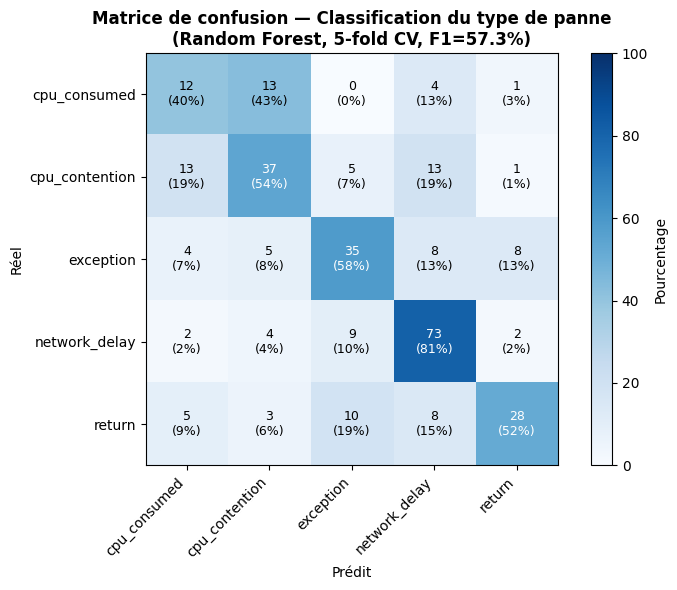

  ✓ 01_matrice_confusion.png


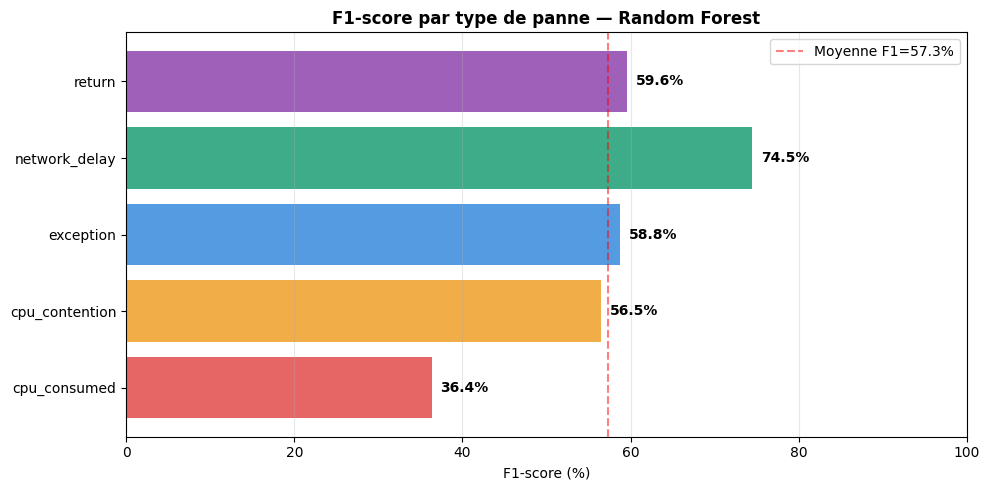

  ✓ 02_f1_par_classe.png


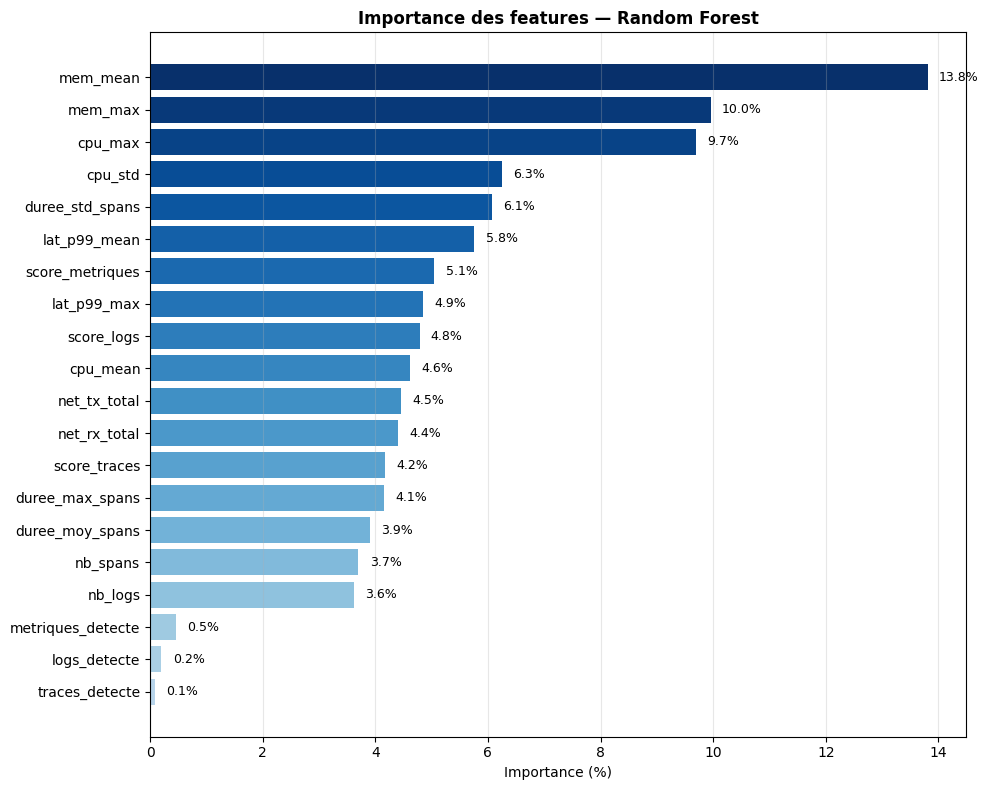

  ✓ 03_feature_importance.png


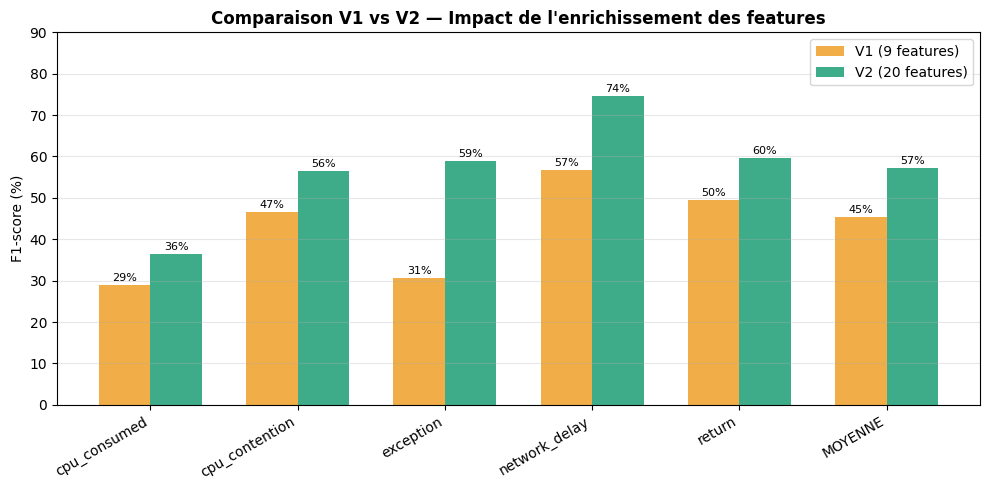

  ✓ 04_comparaison_v1_v2.png

✓ 4 figures générées dans figures/classification_type/


In [13]:
# ═══════════════════════════════════════════
# VISUALISATIONS
# ═══════════════════════════════════════════
print("=== Génération des figures ===\n")

# ─── Figure 1 : Matrice de confusion ───
fig, ax = plt.subplots(figsize=(8, 6))
cm_v2 = confusion_matrix(y_v2, y_pred_v2, labels=classes_ordre)

# Normaliser par classe (pourcentage)
cm_norm = cm_v2.astype('float') / cm_v2.sum(axis=1)[:, np.newaxis] * 100

im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100)

# Annotations
for i in range(cm_v2.shape[0]):
    for j in range(cm_v2.shape[1]):
        text = f'{cm_v2[i,j]}\n({cm_norm[i,j]:.0f}%)'
        color = 'white' if cm_norm[i, j] > 50 else 'black'
        ax.text(j, i, text, ha='center', va='center', color=color, fontsize=9)

ax.set_xticks(range(len(classes_ordre)))
ax.set_yticks(range(len(classes_ordre)))
ax.set_xticklabels(classes_ordre, rotation=45, ha='right')
ax.set_yticklabels(classes_ordre)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion — Classification du type de panne\n(Random Forest, 5-fold CV, F1=57.3%)',
             fontsize=12, fontweight='bold')
plt.colorbar(im, label='Pourcentage')
plt.tight_layout()
plt.savefig(FIGURES / '01_matrice_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ 01_matrice_confusion.png")

# ─── Figure 2 : F1-score par classe ───
fig, ax = plt.subplots(figsize=(10, 5))

f1_scores = [0.364, 0.565, 0.588, 0.745, 0.596]
classes_labels = ['cpu_consumed', 'cpu_contention', 'exception', 'network_delay', 'return']
colors = ['#E24B4A', '#EF9F27', '#378ADD', '#1D9E75', '#8E44AD']

bars = ax.barh(classes_labels, [s*100 for s in f1_scores], color=colors, alpha=0.85)
ax.set_xlabel('F1-score (%)')
ax.set_title('F1-score par type de panne — Random Forest',
             fontsize=12, fontweight='bold')
ax.axvline(x=57.3, color='red', linestyle='--', alpha=0.5, label='Moyenne F1=57.3%')
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)
ax.legend()

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{score*100:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / '02_f1_par_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ 02_f1_par_classe.png")

# ─── Figure 3 : Feature importance ───
fig, ax = plt.subplots(figsize=(10, 8))

importances_sorted = importances.sort_values('importance', ascending=True)
colors_grad = plt.cm.Blues(np.linspace(0.3, 1.0, len(importances_sorted)))

ax.barh(importances_sorted['feature'], importances_sorted['importance']*100,
        color=colors_grad)
ax.set_xlabel('Importance (%)')
ax.set_title('Importance des features — Random Forest',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(importances_sorted.iterrows()):
    ax.text(row['importance']*100 + 0.2, i, f'{row["importance"]*100:.1f}%',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / '03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ 03_feature_importance.png")

# ─── Figure 4 : Comparaison V1 vs V2 ───
fig, ax = plt.subplots(figsize=(10, 5))

classes_labels = ['cpu_consumed', 'cpu_contention', 'exception', 'network_delay', 'return', 'MOYENNE']
f1_v1 = [0.290, 0.466, 0.306, 0.568, 0.495, 0.454]
f1_v2 = [0.364, 0.565, 0.588, 0.745, 0.596, 0.573]

x = np.arange(len(classes_labels))
width = 0.35

ax.bar(x - width/2, [s*100 for s in f1_v1], width, label='V1 (9 features)', color='#EF9F27', alpha=0.85)
ax.bar(x + width/2, [s*100 for s in f1_v2], width, label='V2 (20 features)', color='#1D9E75', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(classes_labels, rotation=30, ha='right')
ax.set_ylabel('F1-score (%)')
ax.set_title('Comparaison V1 vs V2 — Impact de l\'enrichissement des features',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 90)

for i, (v1, v2) in enumerate(zip(f1_v1, f1_v2)):
    ax.text(i - width/2, v1*100 + 1, f'{v1*100:.0f}%', ha='center', fontsize=8)
    ax.text(i + width/2, v2*100 + 1, f'{v2*100:.0f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / '04_comparaison_v1_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ 04_comparaison_v1_v2.png")

print("\n✓ 4 figures générées dans figures/classification_type/")

In [18]:
# ═══════════════════════════════════════════
# FUSION cpu_consumed + cpu_contention
# ═══════════════════════════════════════════
print("=== Fusion des classes CPU ===\n")

# Créer une nouvelle colonne fault_type_v3 avec la fusion
df_features_v3 = df_features_v2.copy()
df_features_v3['fault_type_v3'] = df_features_v3['fault_type'].replace({
    'cpu_consumed'  : 'cpu_problem',
    'cpu_contention': 'cpu_problem',
})

# Nouvelle distribution
print("Distribution après fusion :")
for classe, count in sorted(Counter(df_features_v3['fault_type_v3']).items()):
    print(f"  {classe:<20} : {count} ({count/len(df_features_v3)*100:.1f}%)")

# ═══════════════════════════════════════════
# ENTRAÎNEMENT V3 (4 classes)
# ═══════════════════════════════════════════
print("\n=== Random Forest V3 (4 classes) ===")

X_v3 = df_features_v3[FEATURES_V2].to_numpy().astype(float)
y_v3 = df_features_v3['fault_type_v3'].to_numpy()

rf_v3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

# Cross-validation habituelle
scores_v3 = cross_val_score(rf_v3, X_v3, y_v3, cv=5, scoring='f1_weighted')
print(f"\nCross-validation 5-fold :")
print(f"  F1 par fold : {scores_v3}")
print(f"  Moyenne     : {scores_v3.mean():.3f} ± {scores_v3.std():.3f}")

# Rapport détaillé
print("\n=== Rapport V3 ===")
y_pred_v3 = cross_val_predict(rf_v3, X_v3, y_v3, cv=5, n_jobs=-1)
print(classification_report(y_v3, y_pred_v3, digits=3))

# Matrice de confusion V3
print("=== Matrice de confusion V3 ===")
classes_v3 = sorted(set(y_v3))
cm_v3 = confusion_matrix(y_v3, y_pred_v3, labels=classes_v3)
print(pd.DataFrame(cm_v3, index=classes_v3, columns=classes_v3))

# ═══════════════════════════════════════════
# TEST DU BIAIS SYSTÈME V3
# ═══════════════════════════════════════════
print("\n=== Test du biais système après fusion ===")

mask_tt = df_features_v3['systeme'] == 'train_ticket'
mask_ob = df_features_v3['systeme'] == 'online_boutique'

X_tt = df_features_v3[mask_tt][FEATURES_V2].to_numpy().astype(float)
y_tt = df_features_v3[mask_tt]['fault_type_v3'].to_numpy()

X_ob = df_features_v3[mask_ob][FEATURES_V2].to_numpy().astype(float)
y_ob = df_features_v3[mask_ob]['fault_type_v3'].to_numpy()

# TT → OB
rf_test_tt = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_test_tt.fit(X_tt, y_tt)
y_pred_ob_v3 = rf_test_tt.predict(X_ob)
f1_tt_ob = classification_report(y_ob, y_pred_ob_v3, output_dict=True, zero_division=0)['weighted avg']['f1-score']

# OB → TT
rf_test_ob = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_test_ob.fit(X_ob, y_ob)
y_pred_tt_v3 = rf_test_ob.predict(X_tt)
f1_ob_tt = classification_report(y_tt, y_pred_tt_v3, output_dict=True, zero_division=0)['weighted avg']['f1-score']

print(f"\n  Modèle mixte (5-fold sur tout) : F1 = {scores_v3.mean():.3f}")
print(f"  TT → OB                         : F1 = {f1_tt_ob:.3f}")
print(f"  OB → TT                         : F1 = {f1_ob_tt:.3f}")

# ═══════════════════════════════════════════
# COMPARAISON V2 vs V3
# ═══════════════════════════════════════════
print(f"\n=== Comparaison V2 (5 classes) vs V3 (4 classes) ===")
print(f"  V2 mixte        : F1 = 0.573  (biais système fort)")
print(f"  V3 mixte        : F1 = {scores_v3.mean():.3f}")
print(f"  V2 TT→OB        : F1 = 0.127")
print(f"  V3 TT→OB        : F1 = {f1_tt_ob:.3f}")

=== Fusion des classes CPU ===

Distribution après fusion :
  cpu_problem          : 99 (32.7%)
  exception            : 60 (19.8%)
  network_delay        : 90 (29.7%)
  return               : 54 (17.8%)

=== Random Forest V3 (4 classes) ===

Cross-validation 5-fold :
  F1 par fold : [0.6064666  0.87875726 0.65209301 0.47784852 0.53655172]
  Moyenne     : 0.630 ± 0.138

=== Rapport V3 ===
               precision    recall  f1-score   support

  cpu_problem      0.661     0.727     0.692        99
    exception      0.556     0.500     0.526        60
network_delay      0.750     0.800     0.774        90
       return      0.636     0.519     0.571        54

     accuracy                          0.667       303
    macro avg      0.651     0.636     0.641       303
 weighted avg      0.662     0.667     0.662       303

=== Matrice de confusion V3 ===
               cpu_problem  exception  network_delay  return
cpu_problem             72          9             15       3
exception  

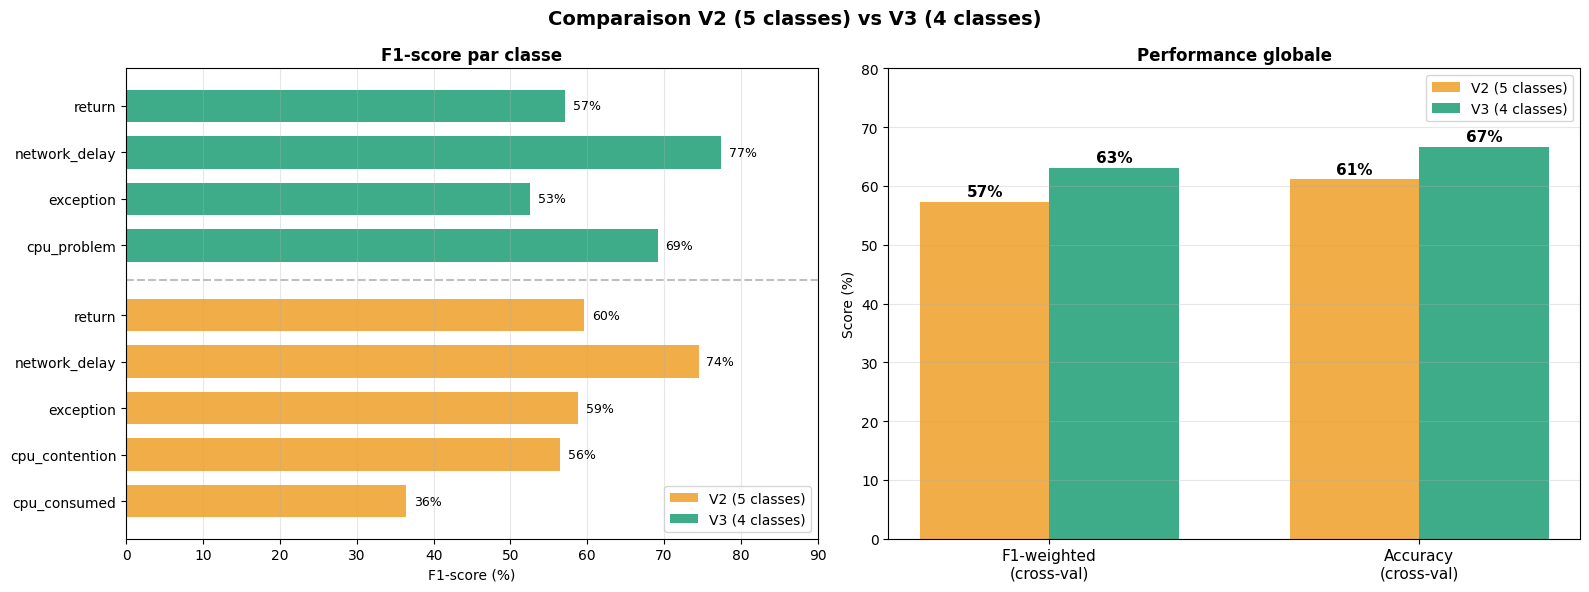

✓ Figure sauvegardée : 05_comparaison_v2_v3.png

BILAN COMPARATIF

  V2 (5 classes distinctes) :
    F1-weighted : 57.3%
    Accuracy    : 61.1%

  V3 (4 classes, fusion des CPU) :
    F1-weighted : 63.0%  (+5.7 pts)
    Accuracy    : 66.7%  (+5.6 pts)

  V3 est plus performant que V2 → on garde V3


In [22]:
# ═══════════════════════════════════════════
# GRAPHIQUE COMPARATIF V2 vs V3
# ═══════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison V2 (5 classes) vs V3 (4 classes)',
             fontsize=14, fontweight='bold')

# ═══════════════════════════════════════════
# GRAPHIQUE 1 : F1 par classe
# ═══════════════════════════════════════════
ax = axes[0]

# Données V2
f1_v2_par_classe = {
    'cpu_consumed'   : 0.364,
    'cpu_contention' : 0.565,
    'exception'      : 0.588,
    'network_delay'  : 0.745,
    'return'         : 0.596,
}

# Données V3
f1_v3_par_classe = {
    'cpu_problem'   : 0.692,
    'exception'     : 0.526,
    'network_delay' : 0.774,
    'return'        : 0.571,
}

# Barres V2
labels_v2 = list(f1_v2_par_classe.keys())
values_v2 = [v * 100 for v in f1_v2_par_classe.values()]
y_v2 = np.arange(len(labels_v2))

# Barres V3 (décalées vers le bas)
labels_v3 = list(f1_v3_par_classe.keys())
values_v3 = [v * 100 for v in f1_v3_par_classe.values()]
y_v3 = np.arange(len(labels_v3)) + len(labels_v2) + 0.5

# Créer les barres
ax.barh(y_v2, values_v2, color='#EF9F27', alpha=0.85, height=0.7, label='V2 (5 classes)')
ax.barh(y_v3, values_v3, color='#1D9E75', alpha=0.85, height=0.7, label='V3 (4 classes)')

# Labels sur l'axe y
all_labels = labels_v2 + [''] + labels_v3
all_positions = list(y_v2) + [y_v2[-1] + 0.75] + list(y_v3)

ax.set_yticks(list(y_v2) + list(y_v3))
ax.set_yticklabels(labels_v2 + labels_v3)

ax.set_xlabel('F1-score (%)')
ax.set_title('F1-score par classe', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 90)

# Annotations
for i, v in enumerate(values_v2):
    ax.text(v + 1, y_v2[i], f'{v:.0f}%', va='center', fontsize=9)
for i, v in enumerate(values_v3):
    ax.text(v + 1, y_v3[i], f'{v:.0f}%', va='center', fontsize=9)

# Séparateur visuel
ax.axhline(y=(y_v2[-1] + y_v3[0]) / 2, color='gray', linestyle='--', alpha=0.5)

# ═══════════════════════════════════════════
# GRAPHIQUE 2 : Performance globale
# ═══════════════════════════════════════════
ax = axes[1]

metriques = ['F1-weighted\n(cross-val)', 'Accuracy\n(cross-val)']
f1_v2_glob = [57.3, 61.1]
f1_v3_glob = [63.0, 66.7]

x = np.arange(len(metriques))
width = 0.35

bars_v2 = ax.bar(x - width/2, f1_v2_glob, width,
                  color='#EF9F27', alpha=0.85, label='V2 (5 classes)')
bars_v3 = ax.bar(x + width/2, f1_v3_glob, width,
                  color='#1D9E75', alpha=0.85, label='V3 (4 classes)')

ax.set_ylabel('Score (%)')
ax.set_title('Performance globale', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metriques, fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 80)

for bar, val in zip(bars_v2, f1_v2_glob):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold')
for bar, val in zip(bars_v3, f1_v3_glob):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / '05_comparaison_v2_v3.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure sauvegardée : 05_comparaison_v2_v3.png")

# ═══════════════════════════════════════════
# RÉSUMÉ TEXTUEL
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("BILAN COMPARATIF")
print("="*60)
print(f"\n  V2 (5 classes distinctes) :")
print(f"    F1-weighted : 57.3%")
print(f"    Accuracy    : 61.1%")
print(f"\n  V3 (4 classes, fusion des CPU) :")
print(f"    F1-weighted : 63.0%  (+5.7 pts)")
print(f"    Accuracy    : 66.7%  (+5.6 pts)")
print(f"\n  V3 est plus performant que V2 → on garde V3")

In [25]:
# ═══════════════════════════════════════════
# SAUVEGARDE V3 (FINAL) — VERSION CORRIGÉE
# ═══════════════════════════════════════════
print("=== Sauvegarde du modèle V3 (final) ===\n")

# Reconstruire X_v3 et y_v3 depuis df_features_v3
X_v3 = df_features_v3[FEATURES_V2].to_numpy().astype(float)
y_v3 = df_features_v3['fault_type_v3'].to_numpy()

print(f"X_v3 shape : {X_v3.shape}")
print(f"y_v3 shape : {y_v3.shape}")
print(f"Classes    : {sorted(set(y_v3))}")

# Entraîner le modèle final V3 sur toutes les données
rf_final_v3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_final_v3.fit(X_v3, y_v3)

# Feature importance V3
importances_v3 = pd.DataFrame({
    'feature'    : FEATURES_V2,
    'importance' : rf_final_v3.feature_importances_,
}).sort_values('importance', ascending=False)

# Écraser l'ancien modèle
with open(MODELS_DIR / 'classifier_type_panne.pkl', 'wb') as f:
    pickle.dump({
        'modele'      : rf_final_v3,
        'features'    : FEATURES_V2,
        'classes'     : sorted(set(y_v3)),
        'f1_weighted' : 0.630,
        'accuracy'    : 0.667,
        'performances': {
            'cpu_problem'  : 0.692,
            'exception'    : 0.526,
            'network_delay': 0.774,
            'return'       : 0.571,
        },
        'features_importantes': importances_v3.head(10).to_dict('records'),
        'note': 'V3 : cpu_consumed et cpu_contention fusionnés en cpu_problem',
    }, f)

print(f"\n✓ Modèle V3 sauvegardé : models/classifier_type_panne.pkl")
print(f"  F1-weighted : 63.0%")
print(f"  Accuracy    : 66.7%")
print(f"\n=== Top 5 features V3 ===")
print(importances_v3.head().to_string(index=False))

=== Sauvegarde du modèle V3 (final) ===

X_v3 shape : (303, 20)
y_v3 shape : (303,)
Classes    : ['cpu_problem', 'exception', 'network_delay', 'return']

✓ Modèle V3 sauvegardé : models/classifier_type_panne.pkl
  F1-weighted : 63.0%
  Accuracy    : 66.7%

=== Top 5 features V3 ===
        feature  importance
       mem_mean    0.144687
        cpu_max    0.111928
        mem_max    0.094915
        cpu_std    0.079079
duree_std_spans    0.055195
